In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, linregress

In [10]:
# ==== CONFIG ====
# REPLICATE_FILE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/all_reps/P0/FMIC/fitness_three_reps_merged.tsv")
REPLICATE_FILE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/FLU/CON/fitness_rep3_with_ids.tsv")
JOINT_FILE     = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Joint_inference/Unfiltered/CON/fitness_union_with_ids.tsv")
OUTPUT_DIR     = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/plots/JointvsIndiv/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
# Cell 3 — load replicate & joint; auto-detect replicate columns; standardize names

import re

# Load replicate fitness data (can be single-rep or 3-rep merged)
rep_df = pd.read_csv(REPLICATE_FILE, sep=r'\s+')
rep_df.columns = [str(c).strip() for c in rep_df.columns]

if "ID" not in rep_df.columns:
    raise ValueError(f"'ID' column not found in {REPLICATE_FILE}. Columns present: {list(rep_df.columns)}")

# Load joint-fit data (only use 'ID' and 's' columns)
joint_df = pd.read_csv(JOINT_FILE, sep=r'\s+')
if not {"ID", "s"}.issubset(joint_df.columns):
    raise ValueError(f"'ID' and 's' columns not both present in {JOINT_FILE}. Columns: {list(joint_df.columns)}")
joint_df = joint_df[["ID", "s"]].rename(columns={"s": "s_joint"})

# --- Detect replicate columns in rep_df ---
# Priority 1: exact known names
priority_exact = ["rep1", "rep2", "rep3", "s_Rep1", "s_Rep2", "s_Rep3", "s"]
present_exact = [c for c in priority_exact if c in rep_df.columns]

# If none of the priority names exist, try regex patterns (rep#, s_Rep#)
if not present_exact:
    pattern_cols = [c for c in rep_df.columns if re.fullmatch(r"(rep\d+|s(_Rep\d+)?)", str(c))]
else:
    pattern_cols = present_exact

# Clean to unique list while preserving order
seen = set()
candidate_cols = [c for c in pattern_cols if not (c in seen or seen.add(c))]

# If still empty, fall back to first numeric-looking column(s) excluding ID and obvious non-fitness cols
if not candidate_cols:
    numeric_cols = []
    for c in rep_df.columns:
        if c == "ID": 
            continue
        # try coercion to detect numeric
        s = pd.to_numeric(rep_df[c], errors="coerce")
        # keep if mostly numeric (>=80% not NaN)
        if s.notna().mean() >= 0.8:
            numeric_cols.append(c)
    # Heuristic: prefer columns literally named 's' if available
    if "s" in numeric_cols:
        candidate_cols = ["s"]
    else:
        candidate_cols = numeric_cols[:3]  # take up to 3 numerics

if not candidate_cols:
    raise ValueError(
        f"Could not find replicate fitness columns in {REPLICATE_FILE}. "
        f"Saw columns: {list(rep_df.columns)}"
    )

# --- Standardize names to rep1/rep2/rep3 in a copy ---
rep_df_std = rep_df[["ID"]].copy()

# Map any of: rep1/2/3, s_Rep1/2/3, or s → rep1..repN in order
REPLICATE_COLS = []
for i, c in enumerate(candidate_cols, start=1):
    newc = f"rep{i}"
    rep_df_std[newc] = pd.to_numeric(rep_df[c], errors="coerce")
    REPLICATE_COLS.append(newc)

# Merge with joint
merged = pd.merge(rep_df_std, joint_df, on="ID", how="inner")

# Ensure numeric
merged["s_joint"] = pd.to_numeric(merged["s_joint"], errors="coerce")

print(f"Merged dataset shape: {merged.shape}")
print(f"Detected replicate columns in input: {candidate_cols} → standardized as {REPLICATE_COLS}")
merged.head()

Merged dataset shape: (79225, 3)
Detected replicate columns in input: ['s'] → standardized as ['rep1']


,ID,rep1,s_joint
0,65742,-0.232191,-0.220531
1,40666,-0.227713,-0.176996
2,74196,-0.223470,-0.154683
3,24969,-0.222577,-0.154117
4,97360,-0.218469,-0.129178


In [12]:
def add_corr_scatter(ax, df, xcol, ycol, label_x, label_y):
    """Draw one scatter + regression line + stats on a given Axes."""
    from scipy.stats import pearsonr, linregress
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    N = len(x)  # number of points used in correlation/regression

    # correlation + regression
    r, p = pearsonr(x, y)
    r2 = r ** 2
    slope, intercept, _, _, _ = linregress(x, y)

    # plot
    ax.scatter(x, y, s=10, alpha=0.5)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, slope * xx + intercept, lw=1.5, color="red", label=f"y = {slope:.2f}x + {intercept:.2f}")

    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="lower right", frameon=False)

    # annotate stats inside panel (now includes N)
    ax.text(0.02, 0.98, f"N = {N}\nR² = {r2:.4f}\np = {p:.2e}",
            transform=ax.transAxes, ha="left", va="top")

    return r, r2, p

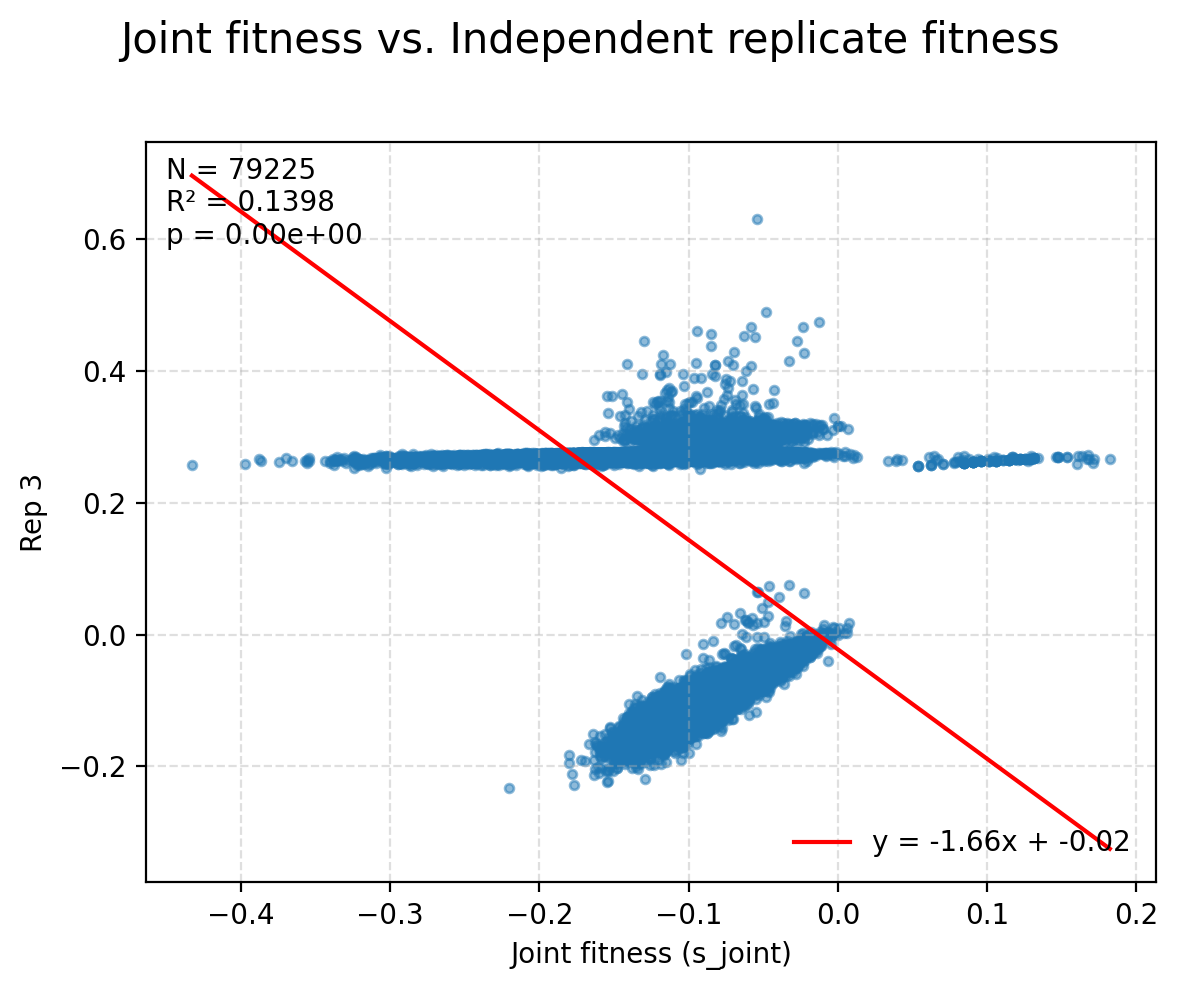

,Replicate,R,R²,p-value
0,Rep 3,-0.373933,0.139826,0.0


Saved figure to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/plots/JointvsIndiv/scatter_joint_vs_reps_1panels.png


In [13]:
# Cell 5 — auto-correct labels for single or multi-rep files

import re

# Try to infer which replicate this file represents if it’s a single-rep file
rep_hint = None
m = re.search(r"rep(\d+)", REPLICATE_FILE.name, flags=re.IGNORECASE)
if m:
    rep_hint = int(m.group(1))

# Build label pairs from standardized replicate columns
pairs = []
if len(REPLICATE_COLS) == 1 and rep_hint:
    # If only one column and file name hints which rep it is
    pairs = [(f"Rep {rep_hint}", REPLICATE_COLS[0])]
else:
    # Otherwise label sequentially
    pairs = [(f"Rep {i+1}", col) for i, col in enumerate(REPLICATE_COLS)]

# Create figure
n = len(pairs)
fig, axes = plt.subplots(
    nrows=1, ncols=n, figsize=(6*n, 5), dpi=200, sharey=True if n > 1 else False
)
if n == 1:
    axes = [axes]

results = []
for ax, (rep_label, y_colname) in zip(axes, pairs):
    r, r2, p = add_corr_scatter(
        ax=ax,
        df=merged,
        xcol="s_joint",
        ycol=y_colname,
        label_x="Joint fitness (s_joint)",
        label_y=rep_label    # <-- use corrected label
    )
    results.append({"Replicate": rep_label, "R": r, "R²": r2, "p-value": p})

subtitle = f"{n} replicate{'s' if n>1 else ''} detected"
fig.suptitle(f"Joint fitness vs. Independent replicate fitness",
             fontsize=15, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save + show
out_name = f"scatter_joint_vs_reps_{n}panels.png"
combined_path = OUTPUT_DIR / out_name
fig.savefig(combined_path)
plt.show()

summary_df = pd.DataFrame(results)
display(summary_df)
print(f"Saved figure to: {combined_path}")